In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os
import graphviz
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
%matplotlib inline

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True) # A real-world binary classification task (income >50K)
dir(adult)

['DESCR',
 'categories',
 'data',
 'details',
 'feature_names',
 'frame',
 'target',
 'target_names',
 'url']

In [3]:
df = pd.DataFrame(adult['data'], columns=adult['feature_names'])
df['target'] = adult['target']
df.shape

(48842, 15)

In [4]:
df['target'].value_counts()

target
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [5]:
df['target'] = df['target'].map({'<=50K': 0, '>50K':1})
df['target'].value_counts()

target
0    37155
1    11687
Name: count, dtype: int64

In [6]:
y = df["target"]
df.drop(columns = ["target"], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [8]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [9]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.select_dtypes(include="category").value_counts()

workclass  education     marital-status      occupation         relationship   race   sex     native-country
Private    HS-grad       Married-civ-spouse  Craft-repair       Husband        White  Male    United-States     1190
           Bachelors     Married-civ-spouse  Exec-managerial    Husband        White  Male    United-States      653
           HS-grad       Married-civ-spouse  Machine-op-inspct  Husband        White  Male    United-States      540
                                             Transport-moving   Husband        White  Male    United-States      504
           Some-college  Married-civ-spouse  Craft-repair       Husband        White  Male    United-States      498
                                                                                                                ... 
State-gov  Some-college  Separated           Adm-clerical       Own-child      Black  Male    United-States        1
                                                                Unmarrie

In [11]:
df.isna().sum() # impute missing categorical values with 'most frequent' values

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [12]:
os.makedirs("images", exist_ok=True)
adult_dot_path = "images/adult.dot"

### Random Forest  
A collection of decision trees built on random subsets of data and features (i.e. bagging).  
Reduces overfitting by averaging the predictions (classification) or mean (regression).  
Better generalization but less interpretable.

### Decision Tree vs. Random Forest vs. Extra Tree 
| Feature                 | **Decision Tree**                    | **Random Forest**                | **Extra Trees** (Extremely Randomized Trees)        |
| ----------------------- | ------------------------------------ | -------------------------------- | --------------------------------------------------- |
| **Model Type**          | Single tree                          | Ensemble of decision trees       | Ensemble of **extremely randomized** trees          |
| **Bagging (Bootstrap)** |  No                                 | Yes                            | No (by default, uses full data sample)            |
| **Feature Sampling**    |  No                                 | Yes (random subset per split)  | Yes                                               |
| **Split Strategy**      | Finds **best** split (greedy search) | Finds **best** split             | Picks **random split thresholds**                   |
| **Randomness**          |  No randomness                      | Some (data + feature sampling) | More (random splits + feature sampling)          |
| **Overfitting Risk**    | High                               | Lower due to averaging         |  Even lower due to extra randomness                |
| **Bias**                | Low                                  | Medium                           | Slightly higher                                     |
| **Variance**            | High                                 | Medium                           | Low                                                 |
| **Training Speed**      | Fast                                 | Medium (100 trees takes time)    | **Fastest** (random split = no optimization needed) |
| **Interpretability**    | Easy                               |  Harder (many trees)            |  Harder                                            |
| **Accuracy**            | Medium                               | High                             | Comparable to Random Forest                         |


### When to use  
| If you want…                        | Use…            |
| ----------------------------------- | --------------- |
| Simplicity, interpretability        | Decision Tree |
| Accuracy & generalization           | Random Forest |
| Faster training, less overfitting   | Extra Trees   |
| Very high-dimensional or noisy data | Extra Trees   |


### Bagging Vs. Boosting Vs. Stacking
| Technique    | Core Idea                                                                                           | Goal                 | Models Combined | Combined How?               | Risk of Overfitting          | Training Style         |
| ------------ | --------------------------------------------------------------------------------------------------- | -------------------- | --------------- | --------------------------- | ---------------------------- | ---------------------- |
| **Bagging**  | Train multiple models **independently** on **random subsets** of data                               | Reduce **variance**  | Homogeneous     | **Average / majority vote** | Low                          | Parallel               |
| **Boosting** | Train models **sequentially**, each correcting the last                                             | Reduce **bias**      | Usually same    | **Weighted sum**            | Medium (overfit if too deep) | Sequential             |
| **Stacking** | Combine multiple models (**different or same types**) by training a **meta-model** on their outputs | Improve **accuracy** | Heterogeneous   | Meta-model (blender)        | Depends on complexity        | Parallel + final layer |


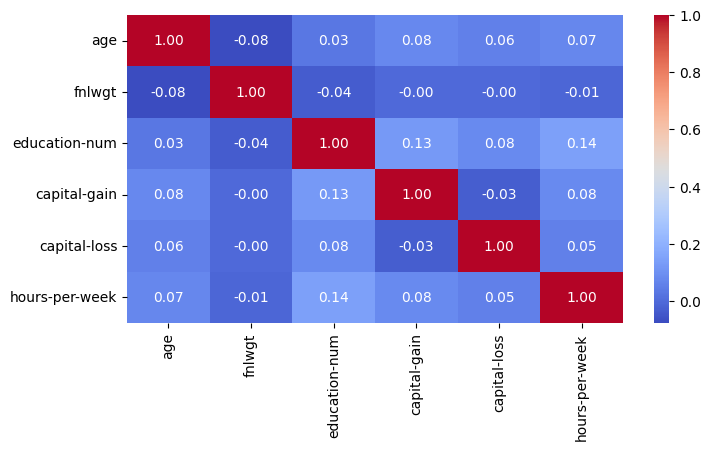

In [13]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

##### Since, we are using ensemble models, we don't need scaling as ensemble models are not sensitive to feature scaling or magnitude

In [14]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((39073, 14), (39073,), (9769, 14), (9769,))

In [15]:
cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

In [16]:
print(cat_cols, num_cols)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country'] ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [17]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehotencoder", OneHotEncoder(drop="first", sparse_output=True))
])

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [18]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [19]:
# Get feature names after transformation
cat_features = preprocessor.named_transformers_['cat']['onehotencoder'].get_feature_names_out(cat_cols)
all_features = list(num_cols) + list(cat_features)
print(len(all_features))
X_train_df = pd.DataFrame(X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed, columns=all_features)
X_test_df = pd.DataFrame(X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed, columns=all_features)
print(X_train_df.shape, X_test_df.shape)

97
(39073, 97) (9769, 97)


# Voting Classifier

In [20]:
voting_clf = VotingClassifier(estimators=[
    ("log_reg", LogisticRegression(random_state=42)),
    ("decision_clf", DecisionTreeClassifier(random_state=42, max_depth=3)),
    ("svc", SVC(random_state=42, probability=True)) # probability=True for getting predict_probabilities
], voting="soft")
voting_clf

VotingClassifier(estimators=[('log_reg', LogisticRegression(random_state=42)),
                             ('decision_clf',
                              DecisionTreeClassifier(max_depth=3,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [21]:
voting_clf.fit(X_train_transformed, y_train)

VotingClassifier(estimators=[('log_reg', LogisticRegression(random_state=42)),
                             ('decision_clf',
                              DecisionTreeClassifier(max_depth=3,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [22]:
for clf in voting_clf.estimators_ + [voting_clf]:
    print(clf.__class__.__name__)
    y_pred = clf.predict(X_test_transformed)
    print(classification_report(y_test, y_pred))

LogisticRegression
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      7431
           1       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769

DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      7431
           1       0.74      0.54      0.63      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.74      0.76      9769
weighted avg       0.84      0.85      0.84      9769

SVC
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.77      0.59      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.85     

In [23]:
voting_clf.named_estimators_["decision_clf"]

DecisionTreeClassifier(max_depth=3, random_state=42)

In [24]:
export_graphviz(voting_clf.named_estimators_["decision_clf"], out_file=adult_dot_path, feature_names=all_features,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True)

In [25]:
!dot -Tpng images/adult.dot -o images/adult.png

# Bagging (Bootstrap aggregation)

Bagging Classifier can take non-tree based extimators as well, but Random Forest is a tree based ensemble method based on Decision tree.

In [26]:
# oob_score = True means the samples that are not used for training, should be utilised for testing
# if bootstrap = False (It becomes pasting instead of bagging i.e. sampling without replacement (the same datapoint won't appear twice in the subsample))
# n_jobs = -1, utlise all available core for training
# bootstrap_features = True i.e. sampling features in the subset
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(splitter="random"), n_estimators=500, oob_score=True, max_samples=10000, bootstrap=True, n_jobs=-1, bootstrap_features=True)
bag_clf.fit(X_train_transformed, y_train)

BaggingClassifier(bootstrap_features=True,
                  estimator=DecisionTreeClassifier(splitter='random'),
                  max_samples=10000, n_estimators=500, n_jobs=-1,
                  oob_score=True)

In [27]:
y_pred = bag_clf.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.78      0.61      0.68      2338

    accuracy                           0.87      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



In [28]:
print(f"oob score: {bag_clf.oob_score_}")

oob score: 0.8640493435364573


### Random Forest (Bootstrap aggregation example)

In [29]:
random_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, oob_score=True)
random_clf.fit(X_train_transformed, y_train)

RandomForestClassifier(max_leaf_nodes=16, n_estimators=500, n_jobs=-1,
                       oob_score=True)

In [30]:
y_pred = bag_clf.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.78      0.61      0.68      2338

    accuracy                           0.87      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



In [31]:
print(f"oob score: {random_clf.oob_score_}")

oob score: 0.8418089217618304


# Boosting  
An ensemble method that combines several weak learners into a strong learner. The general idea is to train predictors sequentially, each trying to correct its predecessor.

### Adaboost (Adaptive Boosting)
Classic example of boosting.  

In [32]:
ada_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(splitter="random", random_state=42, max_depth=1), n_estimators=200, learning_rate=0.5)
ada_clf.fit(X_train_transformed, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42,
                                                    splitter='random'),
                   learning_rate=0.5, n_estimators=200)

In [33]:
y_pred = ada_clf.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7431
           1       0.74      0.58      0.65      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



### Gradient Boosting & Stochastic Gradient Boosting  
Gradient Boosting -  Works by fitting new models to the residual errors of prior models. It minimizes loss function using gradient descent.  
Stochasting Gradient Boosting -  Similar to Gradient Boosting. It fits each new model with random subset of training data and features to avoid overfitting.  

### XGBoost Vs. LightGBM Vs. CatBoost  
| Feature / Framework       | **XGBoost**               | **LightGBM**                             | **CatBoost**                        |
| ------------------------- | --------------------------- | ------------------------------------------- | --------------------------------------- |
| **Language**              | C++ (Python API)            | C++ (Python API)                            | C++ (Python API)                        |
| **Speed**                 | Fast                        | **Very fast**                               | Fast                                    |
| **Accuracy**              | High                        | High (sometimes better)                     | High (especially with categorical data) |
| **Handles Categorical?**  | no,(you must one-hot encode) | Needs label encoding or special config   | yes, **Built-in support**                 |
| **Tree Growth**           | Level-wise (balanced)       | **Leaf-wise** (unbalanced but deeper trees) | Symmetric trees (like XGBoost)          |
| **Memory Usage**          | Moderate                    | Low                                         | Higher than LightGBM                    |
| **GPU Support**           | yes                         | yes                                         | yes                                     |
| **Missing Values**        | yes, Built-in               | yes, Built-in                               | yes, Built-in                              |
| **Best For**              | General use                 | Large datasets / speed                      | Categorical-heavy features              |
| **Interpretability**      | Good                        | Moderate                                    | Good                                    |
| **Hyperparameter tuning** | Needed                      | More sensitive                              | Often works well out of the box         |


In [34]:
# subsample = 0.25, makes it stochastic (use only 25% of the training instance selected randomly)
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, subsample=0.25, max_depth=1)
gb_clf.fit(X_train_transformed, y_train)

GradientBoostingClassifier(learning_rate=0.5, max_depth=1, subsample=0.25)

In [35]:
y_pred = gb_clf.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.78      0.58      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.86      0.86      0.85      9769



##### Xgboost (Extreme Gradient Boosting)

In [36]:
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.5, max_depth=3, use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_clf.fit(X_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [37]:
y_pred = xgb_clf.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.65      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



In [38]:
xgb_clf.get_booster().feature_names = all_features

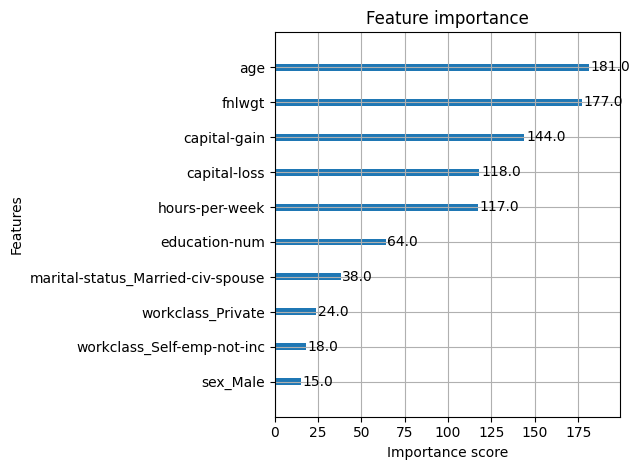

In [39]:
plot_importance(xgb_clf, max_num_features=10)
plt.tight_layout()
plt.show()

##### LightGBM

In [40]:
lgbm = LGBMClassifier(n_estimators=200, random_state=42, learning_rate=0.5, max_depth=3, subsample=0.2)
lgbm.fit(
    X_train_transformed, y_train,
    eval_set=[(X_train_transformed, y_train), (X_test_transformed, y_test)],
    callbacks = [early_stopping(50)],
    eval_metric="auc"
)

[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 782
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

LGBMClassifier(learning_rate=0.5, max_depth=3, n_estimators=200,
               random_state=42, subsample=0.2)

In [41]:
print("Best iteration:", lgbm.best_iteration_)
print("Best AUC:", lgbm.best_score_['valid_1']['auc'])

Best iteration: 72
Best AUC: 0.9283206469004434


In [42]:
y_pred = lgbm.predict(X_test_transformed)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.79      0.64      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



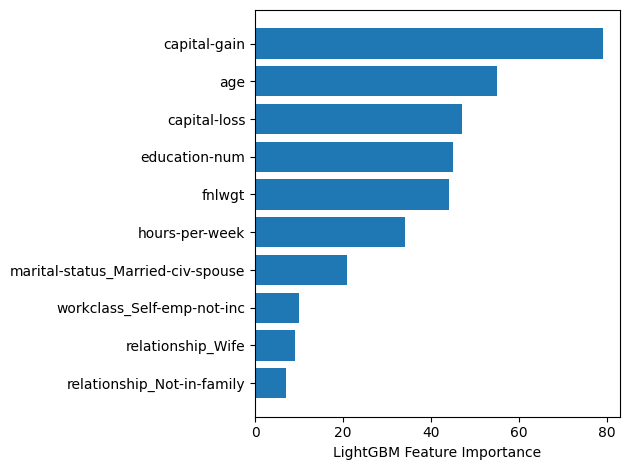

In [43]:
importances = lgbm.feature_importances_
sorted_idx = importances.argsort()[-10:]  # Top 10
plt.barh([all_features[i] for i in sorted_idx], importances[sorted_idx])
plt.xlabel("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

##### Catboost  
Process categorical cols directly without encoding.  

In [44]:
for feat in ["workclass", "occupation", "native-country"]:
    imputer = SimpleImputer(strategy="most_frequent")
    X_train[feat] = imputer.fit_transform(X_train[[feat]]).ravel()
    X_test[feat] = imputer.transform(X_test[[feat]]).ravel()

In [45]:
pool_train = Pool(data=X_train, label=y_train, cat_features = cat_cols)
pool_test = Pool(data=X_test, label=y_test, cat_features = cat_cols)

In [46]:
cat_clf = CatBoostClassifier(n_estimators=100, learning_rate=0.5, random_seed=42, depth=3, early_stopping_rounds=50)
cat_clf.fit(pool_train,  eval_set=pool_test)

0:	learn: 0.4911011	test: 0.4912726	best: 0.4912726 (0)	total: 180ms	remaining: 17.8s
1:	learn: 0.4179373	test: 0.4175614	best: 0.4175614 (1)	total: 218ms	remaining: 10.7s
2:	learn: 0.3825766	test: 0.3833392	best: 0.3833392 (2)	total: 247ms	remaining: 7.97s
3:	learn: 0.3584265	test: 0.3588235	best: 0.3588235 (3)	total: 276ms	remaining: 6.63s
4:	learn: 0.3468313	test: 0.3471032	best: 0.3471032 (4)	total: 310ms	remaining: 5.88s
5:	learn: 0.3345999	test: 0.3344156	best: 0.3344156 (5)	total: 347ms	remaining: 5.43s
6:	learn: 0.3281362	test: 0.3276053	best: 0.3276053 (6)	total: 381ms	remaining: 5.06s
7:	learn: 0.3240677	test: 0.3230532	best: 0.3230532 (7)	total: 417ms	remaining: 4.79s
8:	learn: 0.3207089	test: 0.3199829	best: 0.3199829 (8)	total: 455ms	remaining: 4.6s
9:	learn: 0.3176901	test: 0.3172474	best: 0.3172474 (9)	total: 492ms	remaining: 4.43s
10:	learn: 0.3158653	test: 0.3150648	best: 0.3150648 (10)	total: 527ms	remaining: 4.26s
11:	learn: 0.3135403	test: 0.3125655	best: 0.3125655 

In [47]:
y_pred = cat_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.80      0.64      0.71      2338

    accuracy                           0.87      9769
   macro avg       0.85      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



In [48]:
roc_auc_score(y_test, y_pred)

np.float64(0.7929092791981065)

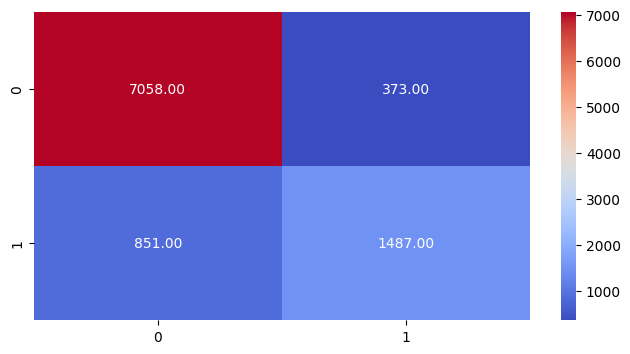

In [49]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,4))
sns.heatmap(cm, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

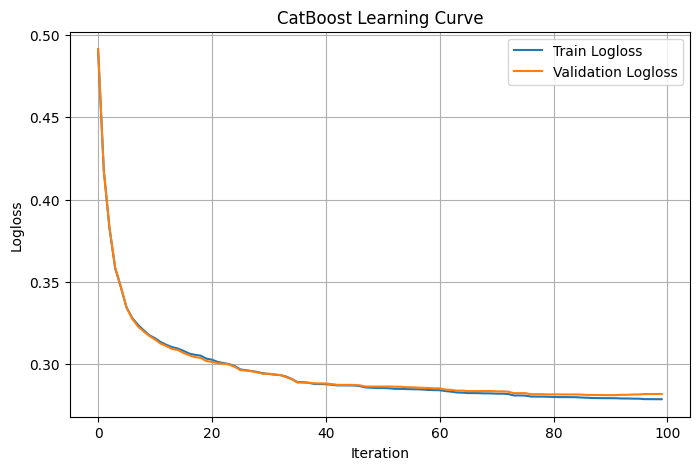

In [50]:
# Extract eval results
evals_result = cat_clf.get_evals_result()

# The key is usually 'validation' for test set and 'learn' for train
train_metric = evals_result['learn']['Logloss']
valid_metric = evals_result['validation']['Logloss']

plt.figure(figsize=(8, 5))
plt.plot(train_metric, label='Train Logloss')
plt.plot(valid_metric, label='Validation Logloss')
plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# Stacking  
Here, we aggregate predictions of several models by training a seperate model to perform aggregation.  

In [51]:
# Base learners
estimators = [
    ("lgbm", LGBMClassifier(n_estimators=100, random_state=42)),
    ("catboost", CatBoostClassifier(iterations=100, verbose=False, random_seed=42)),
    ("xgb", XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="logloss", random_state=42))
]
final_estimator = LogisticRegression(random_state=42)

In [52]:
# create stacking classifier
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1,
    passthrough=False # if True, original features are concatenated with base predictions for meta learner
)
stack_clf.fit(X_train_df, y_train)

StackingClassifier(cv=5,
                   estimators=[('lgbm', LGBMClassifier(random_state=42)),
                               ('catboost',
                                <catboost.core.CatBoostClassifier object at 0x000002BC1F04E440>),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eva...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(random_state=42),
                   n_jobs=-1)

In [53]:
y_pred = stack_clf.predict(X_test_df)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      7431
           1       0.79      0.65      0.72      2338

    accuracy                           0.88      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.88      0.87      9769

